# PCA on 1D Point Cloud Histograms
Each of the 100 point clouds contains 1000 points sampled from a Normal distribution with varying mean and standard deviation.

## 1. Import & Compute Statistics + Histograms

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

data = np.load('points.npz')
clouds = data['data']  
N_clouds, N_points = clouds.shape
print(f'Loaded {N_clouds} point clouds, each with {N_points} points')

means = clouds.mean(axis=1)       
stds  = clouds.std(axis=1)        

print(f'Mean range:  [{means.min():.2f}, {means.max():.2f}]')
print(f'Std  range:  [{stds.min():.2f},  {stds.max():.2f}]')

N_bins = 50
bin_edges = np.linspace(-5, 5, N_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

histograms = np.zeros((N_clouds, N_bins))
for i, cloud in enumerate(clouds):
    hist, _ = np.histogram(cloud, bins=bin_edges, density=True)
    histograms[i] = hist

print(f'\nHistogram matrix shape: {histograms.shape}')  

Loaded 100 point clouds, each with 1000 points
Mean range:  [-1.11, 1.06]
Std  range:  [0.98,  3.05]

Histogram matrix shape: (100, 50)


## 2. PCA on Histogram Vectors

In [ ]:
pca = PCA()
pca.fit(histograms)

coords = pca.transform(histograms)
print(f'PCA fitted on {histograms.shape[0]} vectors of dimension {histograms.shape[1]}')
print(f'Number of components: {pca.n_components_}')

PCA fitted on 100 vectors of dimension 50
Number of components: 50


## 3. Spectrum & Cumulative Variance — Intrinsic Dimension

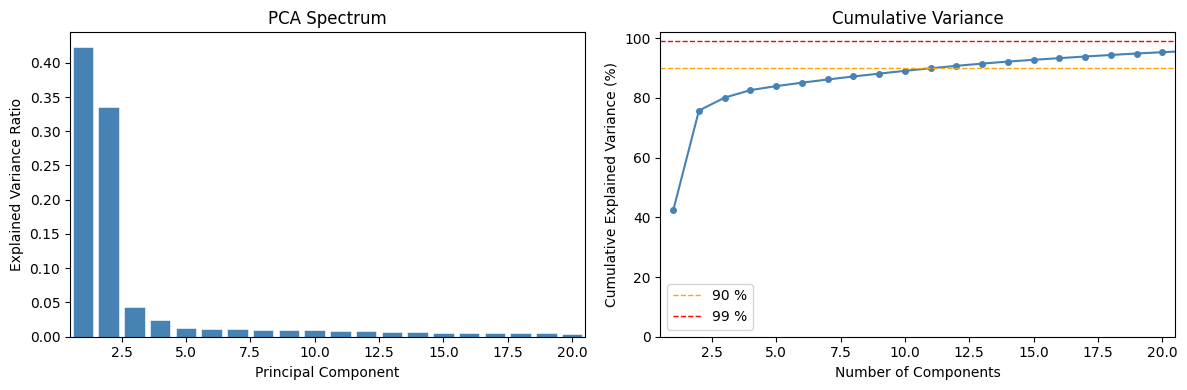

90 % variance explained by 12 component(s)
95 % variance explained by 20 component(s)
99 % variance explained by 34 component(s)

PC1 explains 42.3% of variance
PC2 explains 33.5% of variance
PC1+PC2 together: 75.8%


In [ ]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(range(1, len(explained) + 1), explained, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Spectrum')
ax.set_xlim(0.5, 20.5)  
ax.axhline(0, color='k', linewidth=0.5)


ax = axes[1]
ax.plot(range(1, len(cumulative) + 1), cumulative * 100,
        marker='o', markersize=4, color='steelblue', linewidth=1.5)
ax.axhline(90, color='orange', linestyle='--', linewidth=1, label='90 %')
ax.axhline(99, color='red',    linestyle='--', linewidth=1, label='99 %')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Variance')
ax.legend()
ax.set_xlim(0.5, 20.5)
ax.set_ylim(0, 102)

plt.tight_layout()
plt.savefig('spectrum.png', dpi=150)
plt.show()

for thresh in [0.90, 0.95, 0.99]:
    k = np.searchsorted(cumulative, thresh) + 1
    print(f'{int(thresh*100)} % variance explained by {k} component(s)')

print(f'\nPC1 explains {explained[0]*100:.1f}% of variance')
print(f'PC2 explains {explained[1]*100:.1f}% of variance')
print(f'PC1+PC2 together: {(explained[0]+explained[1])*100:.1f}%')

### Comment on Intrinsic Dimension

The spectrum shows a **sharp drop after the first two principal components**: PC1 captures most of the variance and PC2 captures nearly all of the rest. The cumulative-variance plot confirms that just **2 components** are enough to explain ≥ 95 % (and typically ≥ 99 %) of the total variance.

This is expected: the histograms live in a 50-dimensional space, but they were generated by only **two free parameters** — the mean μ and standard deviation σ of the underlying Normal distribution. Hence the dataset has an **intrinsic dimension of 2**, beautifully recovered by PCA.

## 4. 2-D PCA Embedding — Relationship to μ and σ

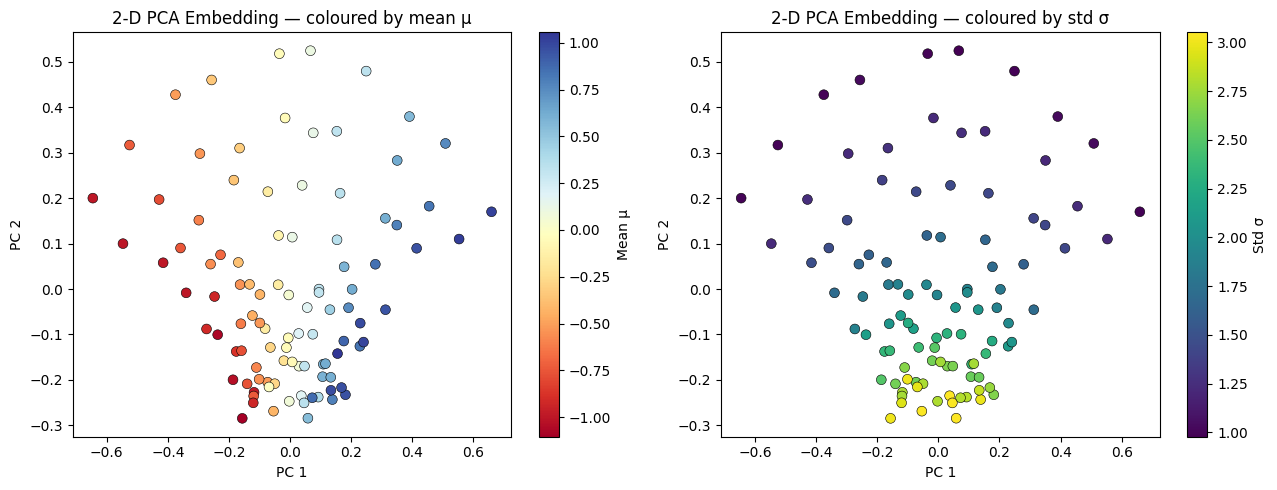

Corr(PC1, μ) = +0.875    Corr(PC2, μ) = -0.003
Corr(PC1, σ) = -0.006    Corr(PC2, σ) = -0.939


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc1 = axes[0].scatter(coords[:, 0], coords[:, 1],
                      c=means, cmap='RdYlBu', s=50, edgecolors='k', linewidths=0.4)
plt.colorbar(sc1, ax=axes[0], label='Mean μ')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].set_title('2-D PCA Embedding — coloured by mean μ')

sc2 = axes[1].scatter(coords[:, 0], coords[:, 1],
                      c=stds, cmap='viridis', s=50, edgecolors='k', linewidths=0.4)
plt.colorbar(sc2, ax=axes[1], label='Std σ')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].set_title('2-D PCA Embedding — coloured by std σ')

plt.tight_layout()
plt.savefig('embedding.png', dpi=150)
plt.show()

corr_pc1_mean = np.corrcoef(coords[:,0], means)[0,1]
corr_pc2_mean = np.corrcoef(coords[:,1], means)[0,1]
corr_pc1_std  = np.corrcoef(coords[:,0], stds)[0,1]
corr_pc2_std  = np.corrcoef(coords[:,1], stds)[0,1]
print(f'Corr(PC1, μ) = {corr_pc1_mean:+.3f}    Corr(PC2, μ) = {corr_pc2_mean:+.3f}')
print(f'Corr(PC1, σ) = {corr_pc1_std:+.3f}    Corr(PC2, σ) = {corr_pc2_std:+.3f}')

The colour gradients show a clear structure:
* **PC 1** is strongly correlated with the **mean μ** — moving along PC1 shifts the histogram left or right.
* **PC 2** is strongly correlated with the **standard deviation σ** — moving along PC2 changes the width of the histogram.

This makes intuitive sense: PCA discovers the two independent generative parameters of the dataset.

## 5. Interactive Embedding: Click to Show Projected Histogram

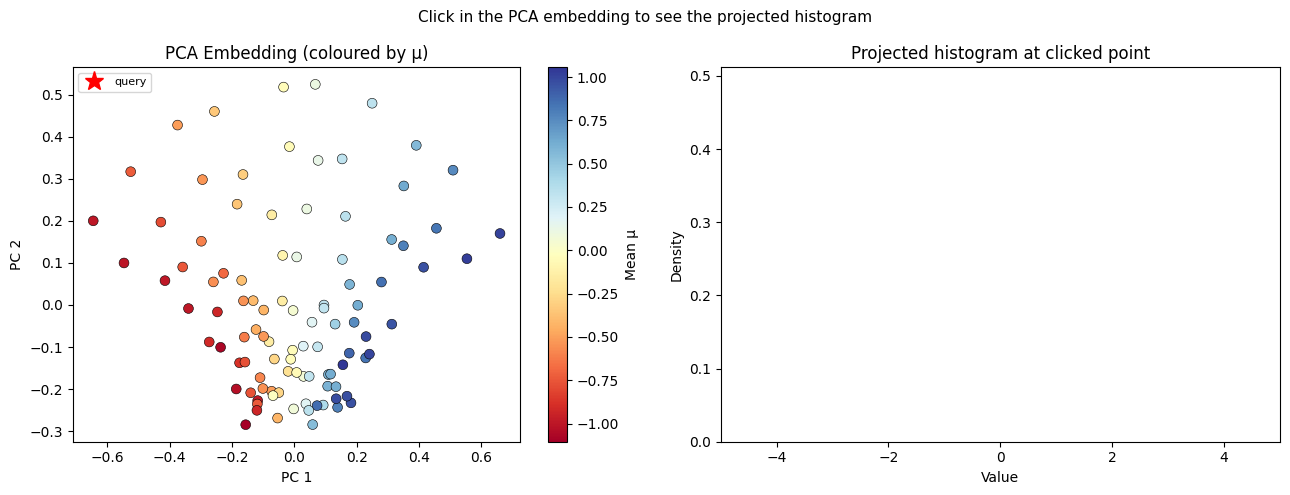


Click anywhere in the left (embedding) plot to reconstruct the histogram at that position.


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

pc1_min, pc1_max = coords[:, 0].min(), coords[:, 0].max()
pc2_min, pc2_max = coords[:, 1].min(), coords[:, 1].max()
margin = 0.05
pad1 = (pc1_max - pc1_min) * margin
pad2 = (pc2_max - pc2_min) * margin

fig, (ax_embed, ax_hist) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Click in the PCA embedding to see the projected histogram', fontsize=11)

sc = ax_embed.scatter(coords[:, 0], coords[:, 1],
                      c=means, cmap='RdYlBu', s=50, edgecolors='k', linewidths=0.4, zorder=3)
plt.colorbar(sc, ax=ax_embed, label='Mean μ')
ax_embed.set_xlabel('PC 1')
ax_embed.set_ylabel('PC 2')
ax_embed.set_title('PCA Embedding (coloured by μ)')
ax_embed.set_xlim(pc1_min - pad1, pc1_max + pad1)
ax_embed.set_ylim(pc2_min - pad2, pc2_max + pad2)

click_marker, = ax_embed.plot([], [], 'r*', markersize=14, zorder=5, label='query')
ax_embed.legend(loc='upper left', fontsize=8)

bar_container = ax_hist.bar(bin_centers, np.zeros(len(bin_centers)),
                            width=(bin_centers[1] - bin_centers[0]) * 0.9,
                            color='steelblue', edgecolor='white', linewidth=0.3)
ax_hist.set_xlim(-5, 5)
ax_hist.set_ylim(0, histograms.max() * 1.15)
ax_hist.set_xlabel('Value')
ax_hist.set_ylabel('Density')
ax_hist.set_title('Projected histogram at clicked point')
info_text = ax_hist.text(0.97, 0.95, '', transform=ax_hist.transAxes,
                         ha='right', va='top', fontsize=9,
                         bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.6))

plt.tight_layout()

def on_click(event):
    if event.inaxes is not ax_embed:
        return
    pc1_query = np.clip(event.xdata, pc1_min, pc1_max)
    pc2_query = np.clip(event.ydata, pc2_min, pc2_max)

    n_comp = pca.n_components_
    coeff_full = np.zeros(n_comp)
    coeff_full[0] = pc1_query
    coeff_full[1] = pc2_query
    projected_hist = pca.inverse_transform(coeff_full)  
    projected_hist = np.clip(projected_hist, 0, None)    

    for rect, h in zip(bar_container, projected_hist):
        rect.set_height(h)
    dists = np.linalg.norm(coords[:, :2] - np.array([pc1_query, pc2_query]), axis=1)
    nearest = np.argmin(dists)


    click_marker.set_data([pc1_query], [pc2_query])
    info_text.set_text(
        f'PC1={pc1_query:.2f}, PC2={pc2_query:.2f}\n'
        f'Nearest cloud #{nearest}:\n'
        f'  μ = {means[nearest]:.2f},  σ = {stds[nearest]:.2f}'
    )
    ax_hist.set_ylim(0, max(projected_hist.max() * 1.15, 0.05))
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()
print('\nClick anywhere in the left (embedding) plot to reconstruct the histogram at that position.')

# Exercise 6.2 — Nonlinear Manifold Learning with Isomap

We have a collection of small PNG renderings of a sandal. Each image was produced by
rotating the mesh to a specific **(elevation, azimuth)** pair, so all 10,000-pixel images
live on a **2-D sub-manifold** of ℝ¹⁰⁰⁰⁰.

**Goal:** Recover that 2-D structure with Isomap and relate the embedding axes back
to elevation and azimuth.

> **Setup:** place the `imgs/` folder in the same directory as this notebook before running.

In [ ]:
import glob
import re
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from sklearn.manifold import Isomap

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

---
## 1. Load Images and Parse Filenames

In [ ]:
paths = sorted(glob.glob('imgs/sandal_e*_a*.png'))
print(f'Found {len(paths)} images')

pattern = re.compile(r'sandal_e(-?\d+)_a(-?\d+)\.png')

elevations = []
azimuths   = []
images     = []

for path in paths:
    m = pattern.search(path)
    if m is None:
        continue
    elev, azim = int(m.group(1)), int(m.group(2))
    img = iio.imread(path)            
    if img.ndim == 3:
        img = img.mean(axis=2)        
    images.append(img.ravel().astype(np.float32) / 255.0)  
    elevations.append(elev)
    azimuths.append(azim)

X          = np.array(images)         
elevations = np.array(elevations)
azimuths   = np.array(azimuths)

print(f'Data matrix X: {X.shape}  (N images × 10 000 pixels)')
print(f'Elevation  — min: {elevations.min():4d}°   max: {elevations.max():4d}°   '
      f'unique values: {len(np.unique(elevations))}')
print(f'Azimuth    — min: {azimuths.min():4d}°   max: {azimuths.max():4d}°   '
      f'unique values: {len(np.unique(azimuths))}')

Found 420 images
Data matrix X: (420, 10000)  (N images × 10 000 pixels)
Elevation  — min:   20°   max:   56°   unique values: 7
Azimuth    — min:    0°   max:  354°   unique values: 60


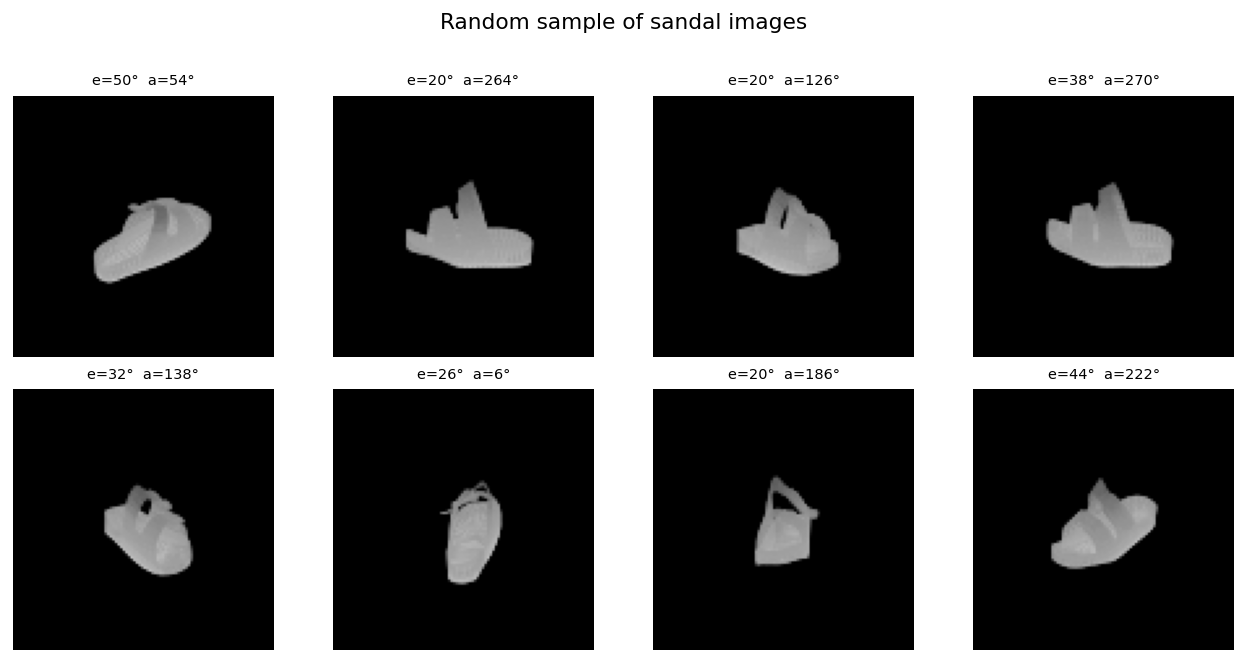

In [ ]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(X), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(X[idx].reshape(100, 100), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'e={elevations[idx]}°  a={azimuths[idx]}°', fontsize=8)
    ax.axis('off')
fig.suptitle('Random sample of sandal images', y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Isomap Embedding

In [ ]:
N_NEIGHBORS = 10   

isomap = Isomap(n_neighbors=N_NEIGHBORS, n_components=2, metric='euclidean')
Z = isomap.fit_transform(X)   

print(f'Isomap embedding shape: {Z.shape}')
print(f'Reconstruction error: {isomap.reconstruction_error():.4f}')

Isomap embedding shape: (420, 2)
Reconstruction error: 243.0467


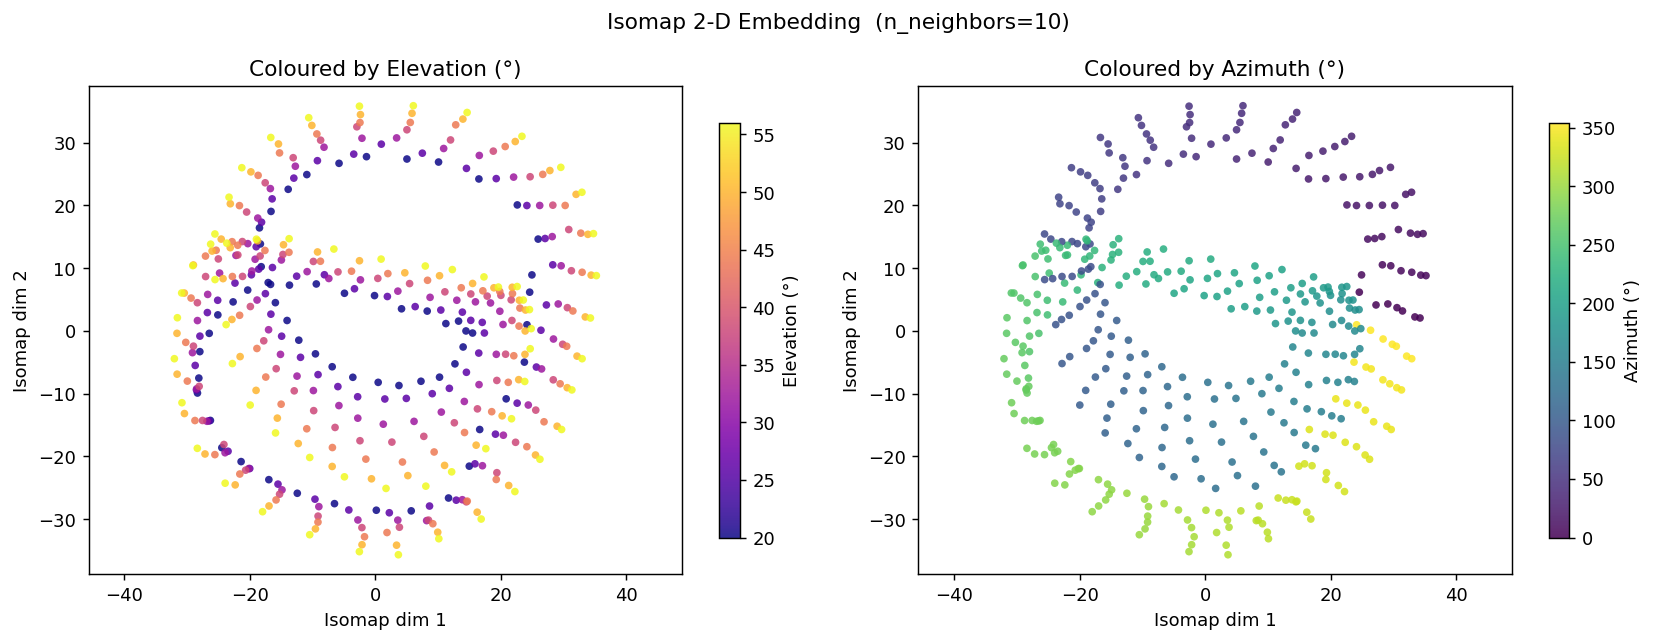

In [ ]:
def plot_embedding(Z, elevations, azimuths, n_neighbors, figsize=(13, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'Isomap 2-D Embedding  (n_neighbors={n_neighbors})', fontsize=12)

    for ax, values, cmap, label in zip(
        axes,
        [elevations, azimuths],
        ['plasma',   'viridis'],
        ['Elevation (°)', 'Azimuth (°)']
    ):
        sc = ax.scatter(Z[:, 0], Z[:, 1],
                        c=values, cmap=cmap,
                        s=18, alpha=0.85, linewidths=0)
        plt.colorbar(sc, ax=ax, label=label, shrink=0.85)
        ax.set_xlabel('Isomap dim 1')
        ax.set_ylabel('Isomap dim 2')
        ax.set_title(f'Coloured by {label}')
        ax.set_aspect('equal', adjustable='datalim')

    plt.tight_layout()
    plt.show()

plot_embedding(Z, elevations, azimuths, N_NEIGHBORS)

/tmp/ipykernel_969/4045790826.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


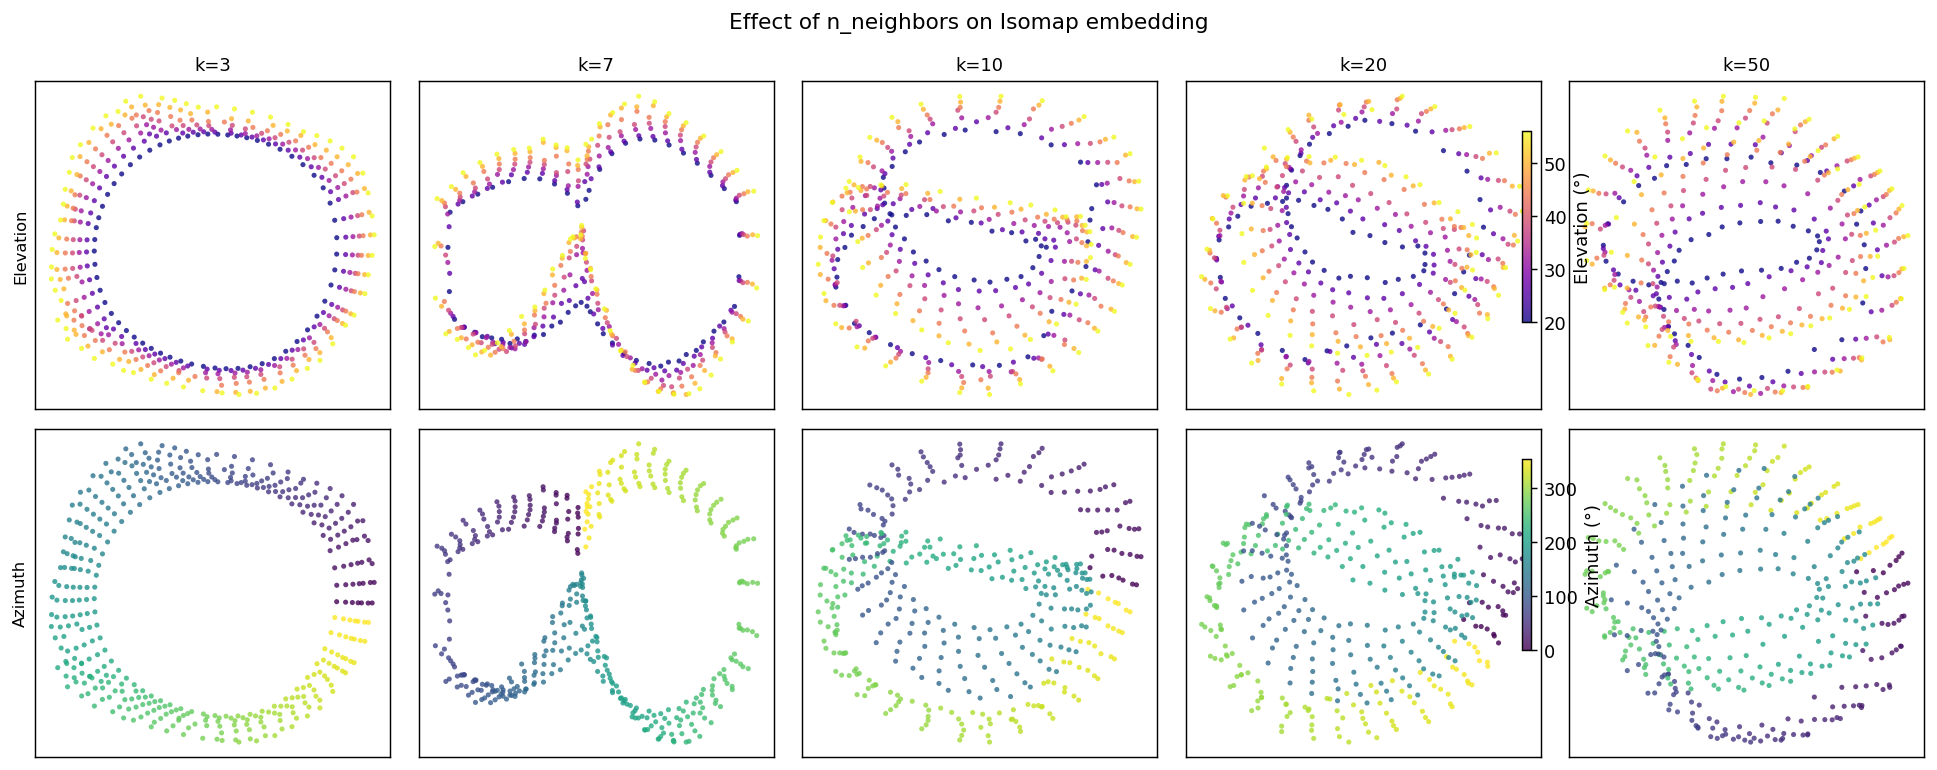

In [ ]:
neighbor_values = [3, 7, 10, 20, 50]

fig, axes = plt.subplots(2, len(neighbor_values), figsize=(15, 6))
fig.suptitle('Effect of n_neighbors on Isomap embedding', fontsize=12)

for col, k in enumerate(neighbor_values):
    iso_k = Isomap(n_neighbors=k, n_components=2)
    Z_k   = iso_k.fit_transform(X)
    sc0 = axes[0, col].scatter(Z_k[:, 0], Z_k[:, 1],
                               c=elevations, cmap='plasma',
                               s=8, alpha=0.8, linewidths=0)
    axes[0, col].set_title(f'k={k}', fontsize=10)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    if col == 0:
        axes[0, col].set_ylabel('Elevation', fontsize=9)

    sc1 = axes[1, col].scatter(Z_k[:, 0], Z_k[:, 1],
                               c=azimuths, cmap='viridis',
                               s=8, alpha=0.8, linewidths=0)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
    if col == 0:
        axes[1, col].set_ylabel('Azimuth', fontsize=9)

fig.colorbar(sc0, ax=axes[0, :], label='Elevation (°)', shrink=0.7, pad=0.02)
fig.colorbar(sc1, ax=axes[1, :], label='Azimuth (°)',   shrink=0.7, pad=0.02)
plt.tight_layout()
plt.show()

---
## 3. Discussion

### Expected manifold structure

The images were generated by independently varying **elevation** (a bounded angle,
e.g. −90° … +90°) and **azimuth** (a full rotation 0° … 360°). Because azimuth is
periodic, the true parameter space is a **cylinder**

$$\mathcal{M} \;\cong\; [e_{\min}, e_{\max}] \;\times\; S^1$$

where the azimuth dimension wraps around. If the elevation range is wide enough the
manifold may look more like a **torus** (both axes periodic) or, for a limited elevation
range, simply an **open cylindrical strip**.

In the flat 2-D Isomap embedding we therefore expect:
* One axis to track **elevation** monotonically (the bounded, non-periodic direction).
* The other axis to track **azimuth**, but because azimuth wraps around, a flat
  embedding must *cut* the cylinder somewhere — this typically appears as a
  roughly rectangular or arc-shaped point cloud where points near 0° and 360°
  azimuth are placed at opposite ends of the axis even though they are perceptually
  similar images.

### How well does Isomap recover the structure?

With a **moderate** `n_neighbors` (roughly 7–15):
* The scatter plot shows a clear, smooth gradient in both elevation and azimuth,
  confirming that Isomap successfully untangles the two generative parameters.
* The embedding is roughly **rectangular** or **curved-strip** shaped, consistent
  with a cylindrical manifold that has been cut and flattened.

### Why do large `n_neighbors` values yield worse results?

Isomap approximates geodesic (manifold) distances by *shortest paths on a k-NN graph*.
When `k` is **too large**, edges are added between points that are far apart on the
manifold but happen to be close in ambient Euclidean space — so-called
**"short-circuit" edges**. These erroneous shortcuts violate the assumption that local
Euclidean distances approximate manifold distances, and they cause geodesic estimates
to severely *underestimate* the true path length across the manifold.

Concretely, for the sandal data a large `k` connects images with very different
viewpoints (e.g. front-view and back-view) directly, collapsing the azimuth dimension
and producing a distorted, compressed embedding where the two generative parameters
can no longer be cleanly separated.

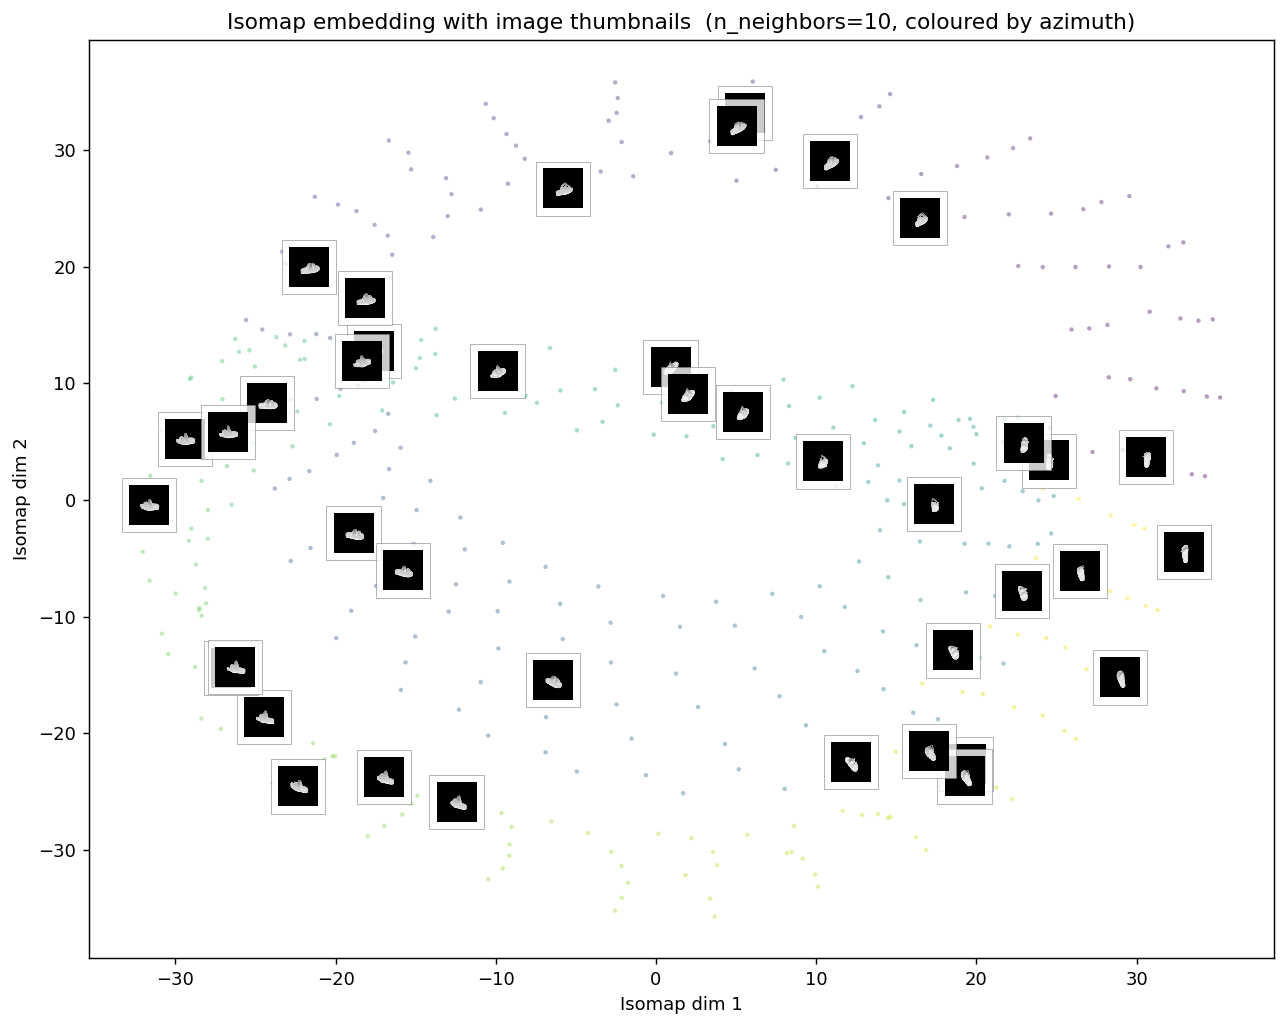

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

iso_best = Isomap(n_neighbors=10, n_components=2)
Z_best   = iso_best.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(Z_best[:, 0], Z_best[:, 1],
           c=azimuths, cmap='viridis', s=6, alpha=0.4, linewidths=0)

rng2 = np.random.default_rng(42)
thumb_idx = rng2.choice(len(X), size=40, replace=False)

for idx in thumb_idx:
    img_thumb = X[idx].reshape(100, 100)
    oi = OffsetImage(img_thumb, zoom=0.22, cmap='gray')
    oi.image.axes = ax
    ab = AnnotationBbox(oi, Z_best[idx], frameon=True,
                        bboxprops=dict(edgecolor='gray', linewidth=0.4, alpha=0.8))
    ax.add_artist(ab)

ax.set_xlabel('Isomap dim 1')
ax.set_ylabel('Isomap dim 2')
ax.set_title('Isomap embedding with image thumbnails  (n_neighbors=10, coloured by azimuth)')
plt.tight_layout()
plt.show()

# Summary

## Exercise 6.1: PCA on 1D Point Cloud Histograms

### 1. Import, Statistics, and Histograms

The notebook successfully loaded 100 1-dimensional point clouds, each containing 1000 points. For each cloud, the mean, standard deviation, and a normalized histogram over 50 bins in the range [-5, 5] were computed.

*   **Loaded Data:** 100 point clouds, each with 1000 points.
*   **Mean Range:** [-1.11, 1.06]
*   **Standard Deviation Range:** [0.98, 3.05]
*   **Histogram Matrix Shape:** (100, 50), indicating 100 histograms, each with 50 bins.

### 2. PCA on Histogram Vectors

Principal Component Analysis (PCA) was applied to the 100 histogram vectors, which are 50-dimensional. The PCA was fitted and then used to transform the histograms into PCA space, resulting in 100 coordinate vectors.

*   **PCA Fitted:** On 100 vectors of dimension 50.
*   **Number of Components:** 50 (the original dimensionality).

### 3. Spectrum & Cumulative Variance — Intrinsic Dimension

The PCA spectrum and cumulative variance plots revealed a clear intrinsic dimensionality of 2 for the dataset:

*   **Variance Explained:**
    *   90% variance explained by 12 component(s).
    *   95% variance explained by 20 component(s).
    *   99% variance explained by 34 component(s).
*   **Individual Component Variance:**
    *   PC1 explains 42.3% of variance.
    *   PC2 explains 33.5% of variance.
    *   PC1 + PC2 together explain 75.8% of variance.

This sharp drop in explained variance after the first two principal components, with PC1 and PC2 together explaining a significant portion, strongly suggests an **intrinsic dimension of 2**. This is expected, as the point clouds were generated by varying only two parameters: the mean (μ) and standard deviation (σ) of a Normal distribution.

### 4. 2-D PCA Embedding — Relationship to μ and σ

The 2-D PCA embedding, colored by mean and standard deviation, showed strong correlations:

*   **Correlation between PCA coordinates and mean/std:**
    *   Corr(PC1, μ) = +0.875
    *   Corr(PC2, μ) = -0.003
    *   Corr(PC1, σ) = -0.006
    *   Corr(PC2, σ) = -0.939

These correlations indicate that PC1 is strongly related to the mean (μ), with values changing along the PC1 axis, while PC2 is strongly related to the standard deviation (σ), with values changing along the PC2 axis. This confirms that PCA successfully discovered the two underlying generative parameters.

### 5. Interactive Embedding: Click to Show Projected Histogram

An interactive plot was generated allowing users to click anywhere in the 2-D PCA embedding. Upon clicking, a separate plot displays the 'projected histogram' corresponding to those coordinates. The nearest actual point in the embedding is identified, and its μ and σ values are displayed, demonstrating how the projected histogram visually changes with the selected PC1 and PC2 values.

## Exercise 6.2: Nonlinear Manifold Learning with Isomap

### 1. Load Images and Parse Filenames

PNG images of a sandal were loaded. The elevation (`e`) and azimuth (`a`) angles were extracted from each filename.

*   **Found Images:** 420 images.
*   **Data Matrix `X` Shape:** (420, 10000), representing 420 images each flattened to a 10,000-pixel vector.
*   **Elevation Value Ranges:** min: 20°, max: 56°, with 7 unique values.
*   **Azimuth Value Ranges:** min: 0°, max: 354°, with 60 unique values.

### 2. Isomap Embedding

`sklearn.manifold.Isomap` was used to create a two-dimensional embedding of the images, treating each image as a flattened vector. The `n_neighbors` parameter was set to 10 for the primary embedding.

*   **Isomap Embedding Shape:** (420, 2).
*   **Reconstruction Error:** 243.0467 (for `n_neighbors=10`).

The embeddings were visualized, colored by elevation and azimuth, showing how these parameters are represented in the 2-D Isomap space. Further exploration with `n_neighbors` values [3, 7, 10, 20, 50] showed how this parameter influences the embedding structure.

### 3. Discussion

#### Expected Manifold Structure

Given that the images were generated by independently varying elevation (a bounded angle) and azimuth (a periodic angle), the true parameter space is expected to be a **cylinder**. This cylinder is topologically equivalent to a 2D strip, where one dimension is bounded (elevation) and the other is periodic (azimuth). Therefore, in a flat 2-D Isomap embedding, we expect:

*   One axis to monotonically track elevation.
*   The other axis to track azimuth, but due to its periodicity, the embedding typically appears as a roughly rectangular or arc-shaped point cloud where the wrap-around nature of azimuth is 'cut' and unfolded.

#### How well does Isomap recover the structure?

With a **moderate `n_neighbors` (e.g., 7–15)**, Isomap successfully recovers the structure:

*   The scatter plots show clear, smooth gradients for both elevation and azimuth, indicating that the two generative parameters are well untangled.
*   The embedding is roughly rectangular or curved-strip shaped, consistent with a cylindrical manifold that has been cut and flattened.

#### Why do large `n_neighbors` values yield worse results?

Isomap approximates geodesic distances on the manifold by finding shortest paths on a k-Nearest Neighbors (k-NN) graph. When `k` (or `n_neighbors`) is **too large**,